AIM :  The goal is to predict whether food delivery will be fast or delayed based on features like customer location, restaurant location, weather conditions, traffic conditions, and more. This task is a binary classification problem where the model will predict delivery status: "Fast" or "Delayed.


In [94]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [95]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
df

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,ORD0196,"(17.910045, 81.56199)","(18.098924, 87.896124)",23.82,Cloudy,High,8,Medium,Night,Bike,4.7,4.0,50.39,1432.26,66.34
196,ORD0197,"(21.66459, 82.226635)","(16.892341, 80.554716)",6.09,Snowy,Medium,8,Low,Night,Bicycle,3.0,3.6,90.54,1720.25,40.27
197,ORD0198,"(14.575401, 82.55641)","(13.625369, 82.418092)",20.61,Snowy,High,4,Medium,Afternoon,Bike,2.9,3.4,73.20,1356.58,5.10
198,ORD0199,"(12.094497, 82.893369)","(19.135509, 86.659978)",24.06,Rainy,High,9,Low,Night,Car,3.9,4.8,53.94,354.39,85.25


Exploratory Data Analysis (EDA)

In [96]:
df.shape

(200, 15)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [98]:
df.isnull().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

### So there are no missing values or null values above, therefore imputation was not required.

In [99]:
(df == "").sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [100]:
df = df.drop_duplicates()

In [101]:

categorical_cols = df.select_dtypes(include = object).columns
categorical_cols

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location',
       'Weather_Conditions', 'Traffic_Conditions', 'Order_Priority',
       'Order_Time', 'Vehicle_Type'],
      dtype='object')

In [102]:

for cols in categorical_cols:
   print(f"\n{cols}:")
   print(df[cols].unique())
    


Order_ID:
['ORD0001' 'ORD0002' 'ORD0003' 'ORD0004' 'ORD0005' 'ORD0006' 'ORD0007'
 'ORD0008' 'ORD0009' 'ORD0010' 'ORD0011' 'ORD0012' 'ORD0013' 'ORD0014'
 'ORD0015' 'ORD0016' 'ORD0017' 'ORD0018' 'ORD0019' 'ORD0020' 'ORD0021'
 'ORD0022' 'ORD0023' 'ORD0024' 'ORD0025' 'ORD0026' 'ORD0027' 'ORD0028'
 'ORD0029' 'ORD0030' 'ORD0031' 'ORD0032' 'ORD0033' 'ORD0034' 'ORD0035'
 'ORD0036' 'ORD0037' 'ORD0038' 'ORD0039' 'ORD0040' 'ORD0041' 'ORD0042'
 'ORD0043' 'ORD0044' 'ORD0045' 'ORD0046' 'ORD0047' 'ORD0048' 'ORD0049'
 'ORD0050' 'ORD0051' 'ORD0052' 'ORD0053' 'ORD0054' 'ORD0055' 'ORD0056'
 'ORD0057' 'ORD0058' 'ORD0059' 'ORD0060' 'ORD0061' 'ORD0062' 'ORD0063'
 'ORD0064' 'ORD0065' 'ORD0066' 'ORD0067' 'ORD0068' 'ORD0069' 'ORD0070'
 'ORD0071' 'ORD0072' 'ORD0073' 'ORD0074' 'ORD0075' 'ORD0076' 'ORD0077'
 'ORD0078' 'ORD0079' 'ORD0080' 'ORD0081' 'ORD0082' 'ORD0083' 'ORD0084'
 'ORD0085' 'ORD0086' 'ORD0087' 'ORD0088' 'ORD0089' 'ORD0090' 'ORD0091'
 'ORD0092' 'ORD0093' 'ORD0094' 'ORD0095' 'ORD0096' 'ORD0097' 'ORD0

Label encoding 

In [103]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Traffic_Conditions"] = le.fit_transform(df["Traffic_Conditions"])
     

df["Traffic_Conditions"].head()

0    2
1    2
2    2
3    1
4    0
Name: Traffic_Conditions, dtype: int64

In [104]:
df.describe().columns

Index(['Distance', 'Traffic_Conditions', 'Delivery_Person_Experience',
       'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost',
       'Tip_Amount'],
      dtype='object')

Outlier Detection :  Detecting outliers in numerical features using boxplots and others to handle them appropriately.


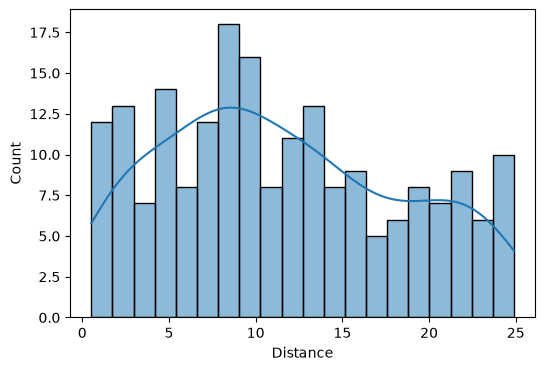

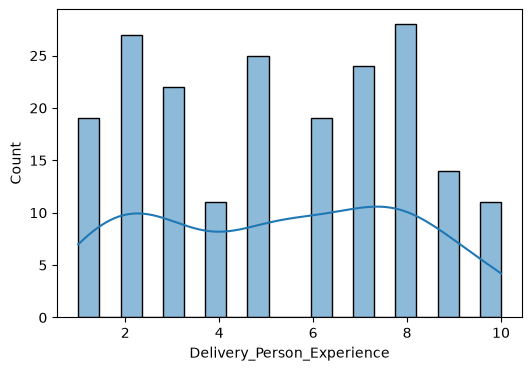

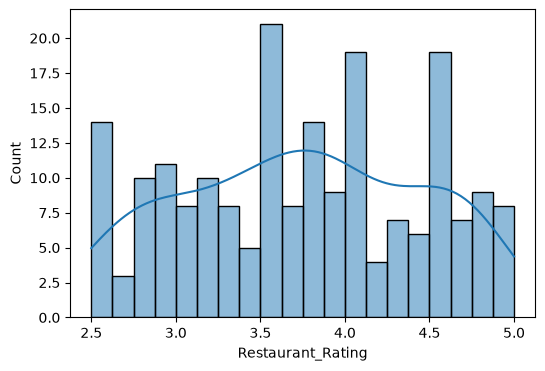

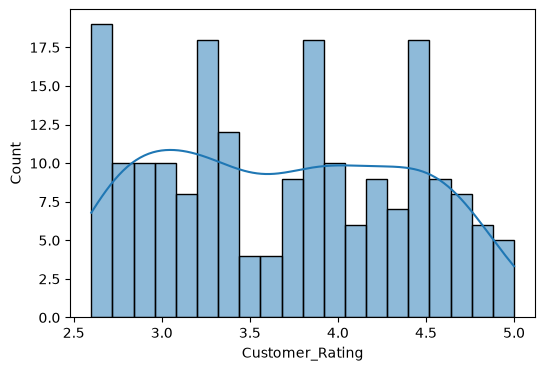

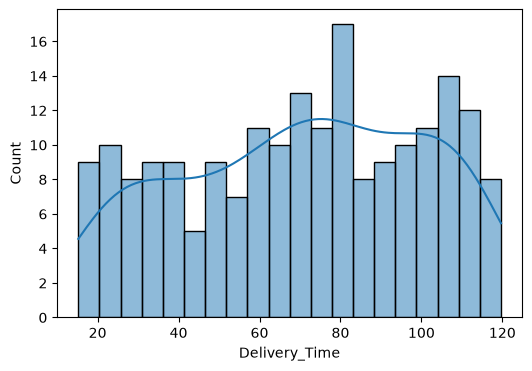

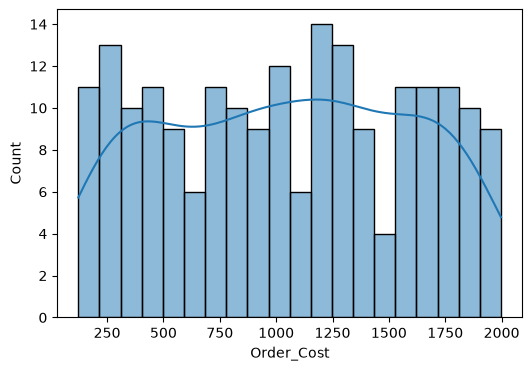

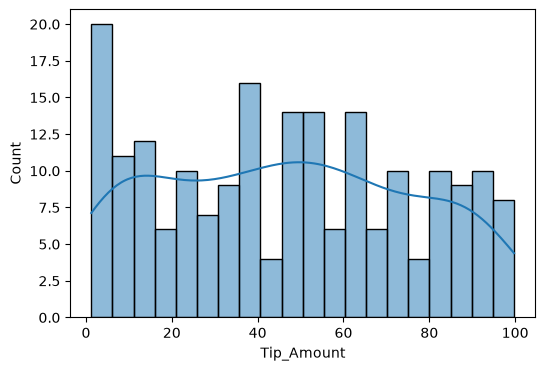

In [105]:
numeric_columns = ['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating',
       'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']
for num_cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[num_cols] ,kde = True,bins = 20  )

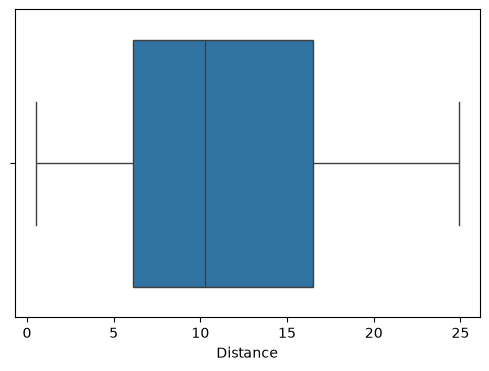

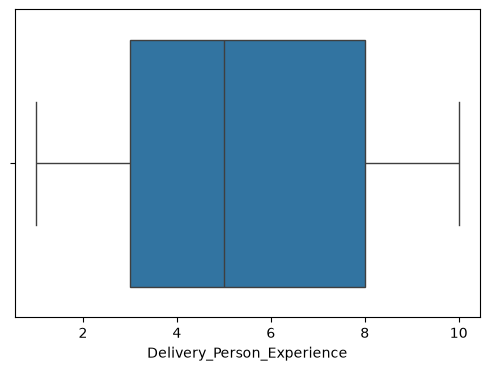

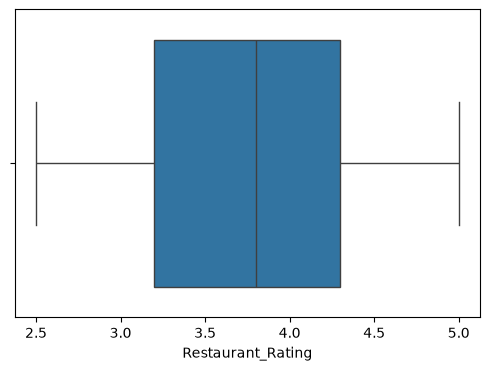

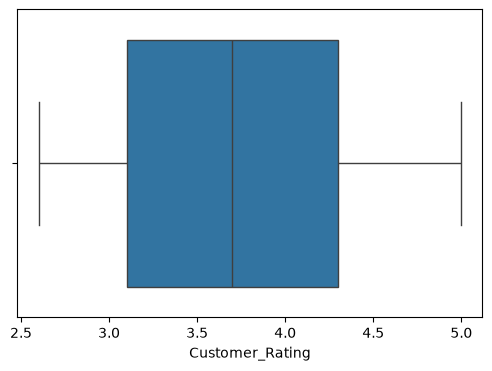

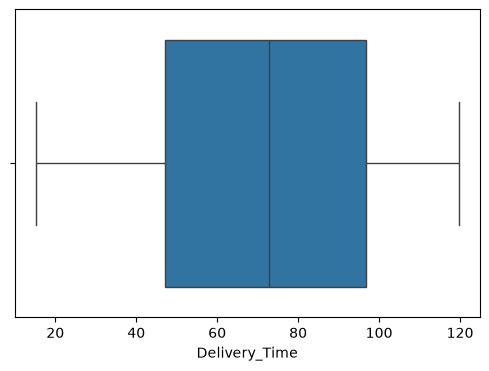

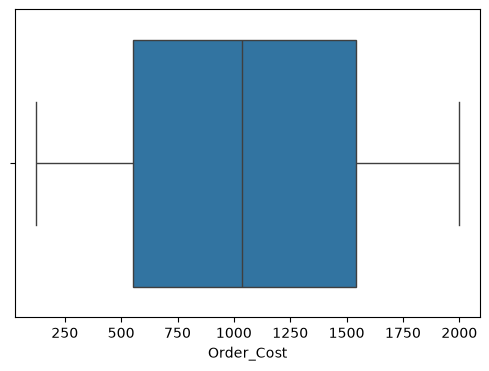

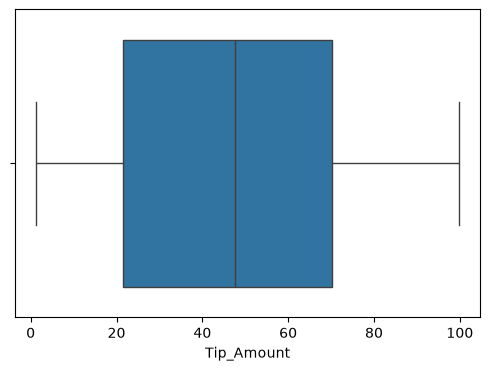

In [106]:
for num_cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[num_cols])

No-outliers here till now 

In [107]:
df_new = df.drop(columns=['Order_ID'])

In [108]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_Location           200 non-null    object 
 1   Restaurant_Location         200 non-null    object 
 2   Distance                    200 non-null    float64
 3   Weather_Conditions          200 non-null    object 
 4   Traffic_Conditions          200 non-null    int64  
 5   Delivery_Person_Experience  200 non-null    int64  
 6   Order_Priority              200 non-null    object 
 7   Order_Time                  200 non-null    object 
 8   Vehicle_Type                200 non-null    object 
 9   Restaurant_Rating           200 non-null    float64
 10  Customer_Rating             200 non-null    float64
 11  Delivery_Time               200 non-null    float64
 12  Order_Cost                  200 non-null    float64
 13  Tip_Amount                  200 non

Feature Engineering

Distance Calculation : 
Calculating the distance between the customer and restaurant using latitudes and longitudes (Haversine formula).


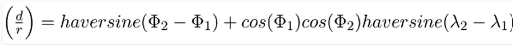
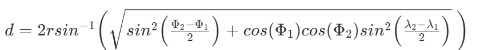

In [109]:

import pandas as pd
import math
import ast

# Takes each values of columns then, convert the string into the actual Python object
df_new["Customer_Location"] = df_new["Customer_Location"].apply(ast.literal_eval) 
df_new["Restaurant_Location"] = df_new["Restaurant_Location"].apply(ast.literal_eval)

def haversine(customer_loc, restaurant_loc):
    lat1, lon1 = customer_loc
    lat2, lon2 = restaurant_loc

    R = 6371 # it is average radius of Earth in km.

    # Here converting degrees to radians as python trigonometric functions need radians, not degrees.

    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2]) 

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Using the above formula in the images 

    a = (math.sin(dlat / 2) ** 2 +
         math.cos(lat1) * math.cos(lat2) *
         math.sin(dlon / 2) ** 2)

    c = 2 * math.asin(math.sqrt(a))

    return R * c

""" using the lambda function here which takes row as parameter and go to the haversine function , 
   just like selecting values from index in list we are selecting 
   "Customer_Location"and "Restaurant_Location" from row , The row , Pandas passes it automatically """    

df_new["locations_distance"] = df_new.apply( 

    lambda row: haversine(
        row["Customer_Location"],
        row["Restaurant_Location"]
    ),
    axis=1
)

df_new.head()

,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance
0,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,2,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,775.651198
1,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,2,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,1042.385597
2,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,2,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,476.220706
3,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,1,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,389.912629
4,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,0,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,806.505886


In [110]:
df_new = df_new.drop(columns=['Customer_Location','Restaurant_Location'])


In [111]:
df_new.head()

,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance
0,1.57,Rainy,2,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,775.651198
1,21.32,Cloudy,2,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,1042.385597
2,6.95,Snowy,2,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,476.220706
3,13.79,Cloudy,1,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,389.912629
4,6.72,Rainy,0,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,806.505886


Time-Based Features:
 Here created new features related to the time of day, such as Rush Hour vs Non-Rush Hour, to improve predictions.


In [112]:
df_new["Rush_Hour"] = df_new["Order_Time"].map({
    "Morning": "Rush",
    "Afternoon": "Rush",
    "Evening": "Rush",
    "Night": "Non-Rush"
})

In [113]:
df_new.head().columns

Index(['Distance', 'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount', 'locations_distance', 'Rush_Hour'],
      dtype='object')

Correlation Analysis :
 Visualizing correlations between features and the target variable (Delivery_Time) to identify the most relevant predictors.


<Axes: >

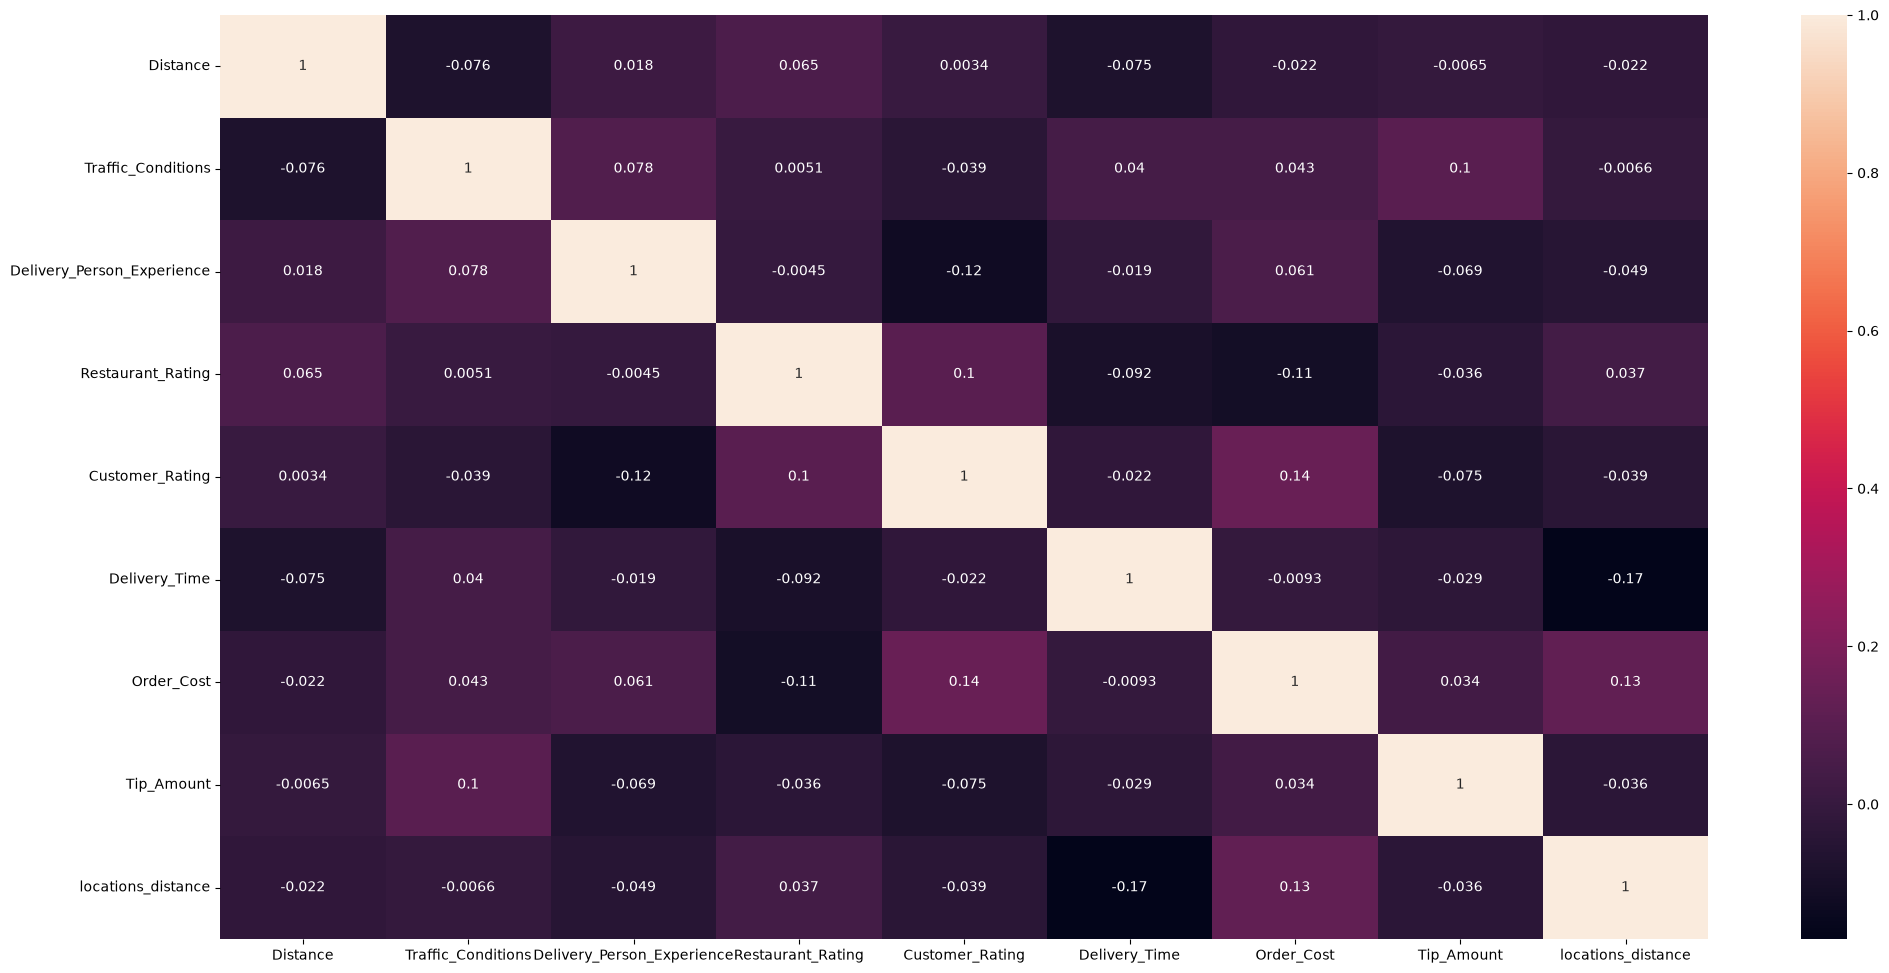

In [114]:
plt.figure(figsize=(24,12))
sns.heatmap(df_new.corr(numeric_only=True), annot=True)

In [115]:
categorical_cols = df_new.select_dtypes(include = object).columns
categorical_cols

Index(['Weather_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type',
       'Rush_Hour'],
      dtype='object')

Using one-hot encoding for categorical Variables

In [116]:
df_new = pd.get_dummies(df_new,columns=['Weather_Conditions', 'Order_Priority',
       'Order_Time', 'Vehicle_Type', 'Rush_Hour']  )
df_new

,Distance,Traffic_Conditions,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance,Weather_Conditions_Cloudy,...,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Rush_Hour_Non-Rush,Rush_Hour_Rush
0,1.57,2,4,4.1,3.0,26.22,1321.10,81.54,775.651198,False,...,True,True,False,False,False,False,False,True,False,True
1,21.32,2,8,4.5,4.2,62.61,152.21,29.02,1042.385597,True,...,False,False,False,False,True,False,False,True,True,False
2,6.95,2,9,3.3,3.4,48.43,1644.38,64.17,476.220706,False,...,False,False,False,False,True,False,True,False,True,False
3,13.79,1,2,3.2,3.7,111.63,541.25,79.23,389.912629,True,...,True,False,True,False,False,False,True,False,False,True
4,6.72,0,6,3.5,2.8,32.38,619.81,2.34,806.505886,False,...,False,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,23.82,0,8,4.7,4.0,50.39,1432.26,66.34,670.130652,True,...,True,False,False,False,True,False,True,False,True,False
196,6.09,2,8,3.0,3.6,90.54,1720.25,40.27,558.891202,False,...,False,False,False,False,True,True,False,False,True,False
197,20.61,0,4,2.9,3.4,73.20,1356.58,5.10,106.686689,False,...,True,True,False,False,False,False,True,False,False,True
198,24.06,0,9,3.9,4.8,53.94,354.39,85.25,880.580093,False,...,False,False,False,False,True,False,False,True,True,False


In [117]:
categorical_cols

Index(['Weather_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type',
       'Rush_Hour'],
      dtype='object')

Typecasting the bool to int type

In [118]:
bool_cols = df_new.select_dtypes(include='bool').columns
df_new[bool_cols] = df_new[bool_cols].astype(int)

In [119]:
df_new

,Distance,Traffic_Conditions,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance,Weather_Conditions_Cloudy,...,Order_Priority_Medium,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Rush_Hour_Non-Rush,Rush_Hour_Rush
0,1.57,2,4,4.1,3.0,26.22,1321.10,81.54,775.651198,0,...,1,1,0,0,0,0,0,1,0,1
1,21.32,2,8,4.5,4.2,62.61,152.21,29.02,1042.385597,1,...,0,0,0,0,1,0,0,1,1,0
2,6.95,2,9,3.3,3.4,48.43,1644.38,64.17,476.220706,0,...,0,0,0,0,1,0,1,0,1,0
3,13.79,1,2,3.2,3.7,111.63,541.25,79.23,389.912629,1,...,1,0,1,0,0,0,1,0,0,1
4,6.72,0,6,3.5,2.8,32.38,619.81,2.34,806.505886,0,...,0,0,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,23.82,0,8,4.7,4.0,50.39,1432.26,66.34,670.130652,1,...,1,0,0,0,1,0,1,0,1,0
196,6.09,2,8,3.0,3.6,90.54,1720.25,40.27,558.891202,0,...,0,0,0,0,1,1,0,0,1,0
197,20.61,0,4,2.9,3.4,73.20,1356.58,5.10,106.686689,0,...,1,1,0,0,0,0,1,0,0,1
198,24.06,0,9,3.9,4.8,53.94,354.39,85.25,880.580093,0,...,0,0,0,0,1,0,0,1,1,0


Checking for outlier in the new 'locations_distance' column

<Axes: xlabel='locations_distance'>

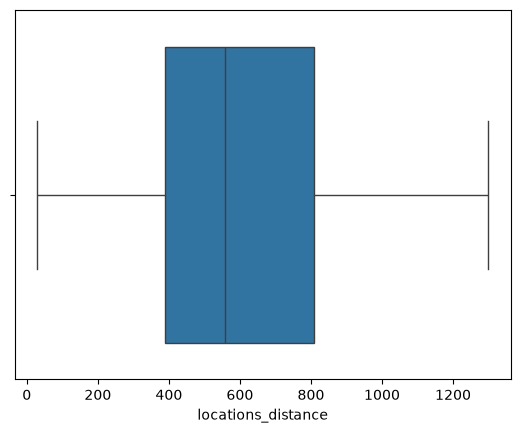

In [120]:
sns.boxplot(x = df_new['locations_distance'])

Standardize Numeric Columns: Standardize the continuous features 'Delivery_Time' for  consistency.


In [121]:

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# df[["Delivery_Time"]] = scaler.fit_transform(df[["Delivery_Time"]])

In [122]:
df_new.head().columns

Index(['Distance', 'Traffic_Conditions', 'Delivery_Person_Experience',
       'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost',
       'Tip_Amount', 'locations_distance', 'Weather_Conditions_Cloudy',
       'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy',
       'Weather_Conditions_Sunny', 'Order_Priority_High', 'Order_Priority_Low',
       'Order_Priority_Medium', 'Order_Time_Afternoon', 'Order_Time_Evening',
       'Order_Time_Morning', 'Order_Time_Night', 'Vehicle_Type_Bicycle',
       'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Rush_Hour_Non-Rush',
       'Rush_Hour_Rush'],
      dtype='object')

In [123]:
df_new['Delivery_Time'].head(4)

0     26.22
1     62.61
2     48.43
3    111.63
Name: Delivery_Time, dtype: float64

Finding the mid-point in the 'Delivery_Time' fetures which give the 'Delivery_Status' such as "Fast"(1) or "Delayed"(0).

In [124]:
df_new['Delivery_Time'].median()

np.float64(72.775)

In [125]:
def check_status(x): 
    if x > 72.775:
        return 1
    else:
        return 0

df_new["Delivery_Status"] = df_new["Delivery_Time"].apply(check_status)

In [126]:
df_new.columns

Index(['Distance', 'Traffic_Conditions', 'Delivery_Person_Experience',
       'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost',
       'Tip_Amount', 'locations_distance', 'Weather_Conditions_Cloudy',
       'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy',
       'Weather_Conditions_Sunny', 'Order_Priority_High', 'Order_Priority_Low',
       'Order_Priority_Medium', 'Order_Time_Afternoon', 'Order_Time_Evening',
       'Order_Time_Morning', 'Order_Time_Night', 'Vehicle_Type_Bicycle',
       'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Rush_Hour_Non-Rush',
       'Rush_Hour_Rush', 'Delivery_Status'],
      dtype='object')

In [127]:
X = df_new[[
   'Distance', 'Traffic_Conditions', 'Delivery_Person_Experience',
        'Order_Cost',
       'Tip_Amount', 'locations_distance', 'Weather_Conditions_Cloudy',
       'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy',
       'Weather_Conditions_Sunny', 'Order_Priority_High', 'Order_Priority_Low',
       'Order_Priority_Medium', 'Order_Time_Afternoon', 'Order_Time_Evening',
       'Order_Time_Morning', 'Order_Time_Night', 'Vehicle_Type_Bicycle',
       'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Rush_Hour_Non-Rush',
       'Rush_Hour_Rush'
    
    ]]
y = df_new['Delivery_Status']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,  stratify=y, test_size=0.2, random_state=42) # since it is using the discrete not continious value so we are using stratify = y

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [129]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


nb = GaussianNB()

nb.fit(X_train_scaled, y_train)


y_pred_nb = nb.predict(X_test_scaled)


print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.425
Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.50      0.47        20
           1       0.41      0.35      0.38        20

    accuracy                           0.42        40
   macro avg       0.42      0.42      0.42        40
weighted avg       0.42      0.42      0.42        40

Confusion Matrix:
 [[10 10]
 [13  7]]


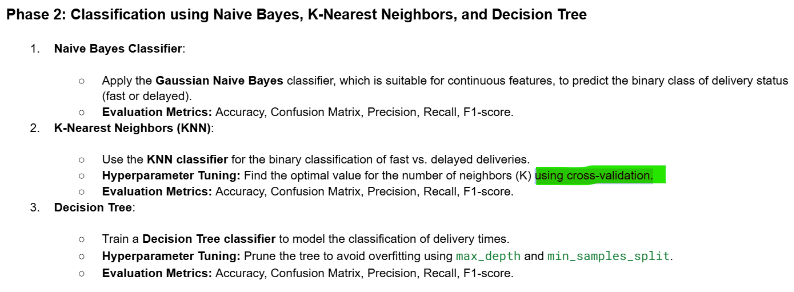 <br>

In my task it ask only for knn --> CV(cross validation)?

In [ ]:
from sklearn.model_selection import cross_val_score 
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

k_values = range(1, 21)
cv_scores = []


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())



In [131]:
for i in cv_scores:
    print(i)

0.5125
0.49375
0.50625
0.4875
0.49375
0.51875
0.50625
0.5
0.4875
0.5125
0.51875
0.5375
0.5
0.50625
0.5
0.49375
0.48125
0.50625
0.50625
0.51875


In [132]:
best_k = k_values[cv_scores.index(max(cv_scores))]
print("Best K:", best_k)
print("Best CV Accuracy:", max(cv_scores))


knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)


y_pred = knn.predict(X_test_scaled)

Best K: 12
Best CV Accuracy: 0.5375


In [133]:
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

 Accuracy: 0.5
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50        20
           1       0.50      0.50      0.50        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.50        40
weighted avg       0.50      0.50      0.50        40

Confusion Matrix:
 [[10 10]
 [10 10]]


In [134]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



dt = DecisionTreeClassifier(
    criterion='gini',   # using gini we getting more     
    max_depth=5,             
    min_samples_split=10,    
    random_state=42
)
dt.fit(X_train_scaled, y_train)


y_pred_dt = dt.predict(X_test_scaled)


print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.50      0.56        20
           1       0.58      0.70      0.64        20

    accuracy                           0.60        40
   macro avg       0.60      0.60      0.60        40
weighted avg       0.60      0.60      0.60        40

Confusion Matrix:
 [[10 10]
 [ 6 14]]


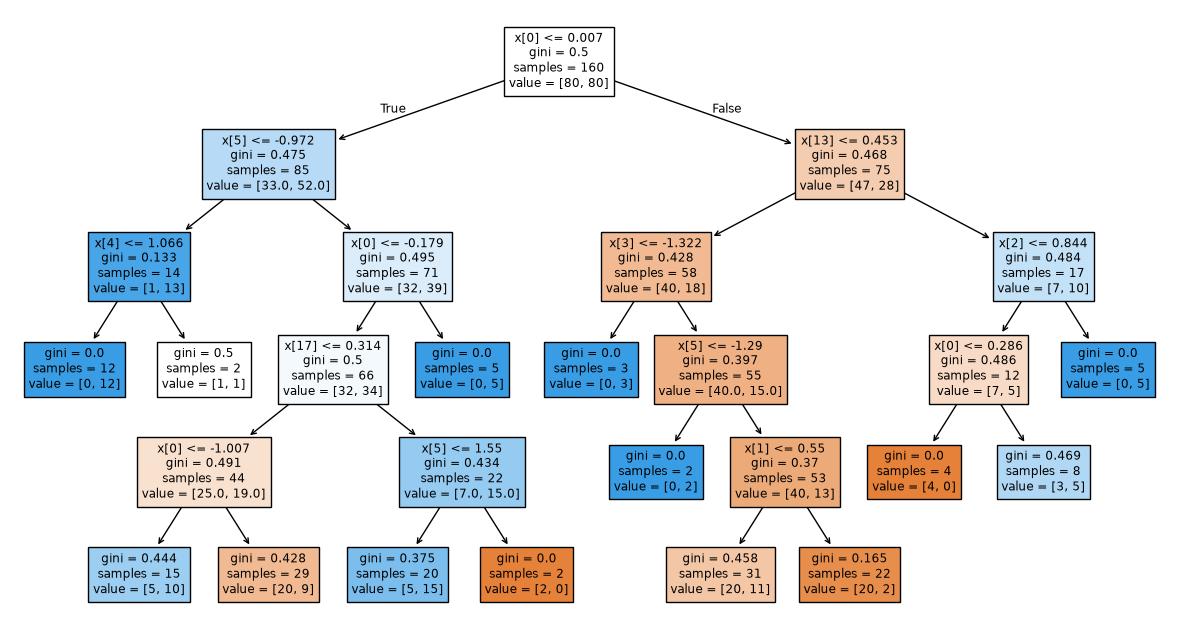

In [135]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(dt, filled=True)
plt.show()

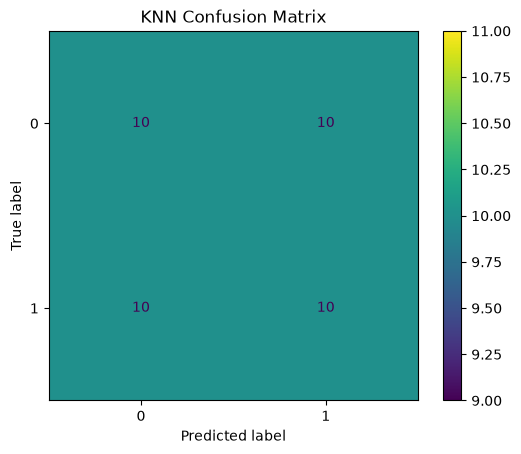

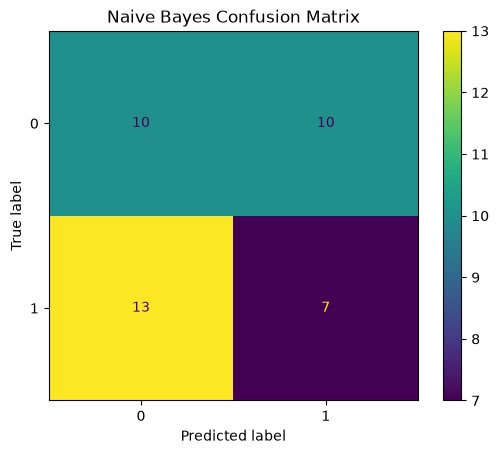

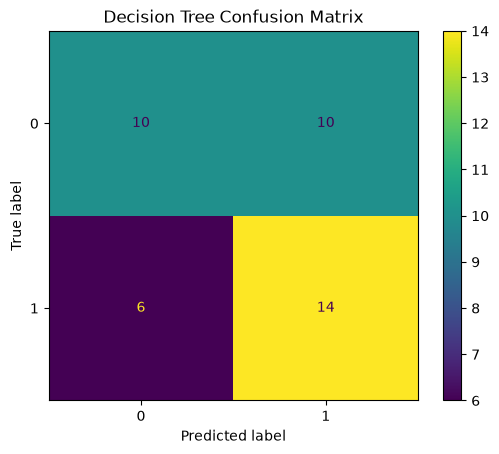

In [136]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("KNN Confusion Matrix")
plt.show()



ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb)
plt.title("Naive Bayes Confusion Matrix")
plt.show()




ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Decision Tree Confusion Matrix")
plt.show()

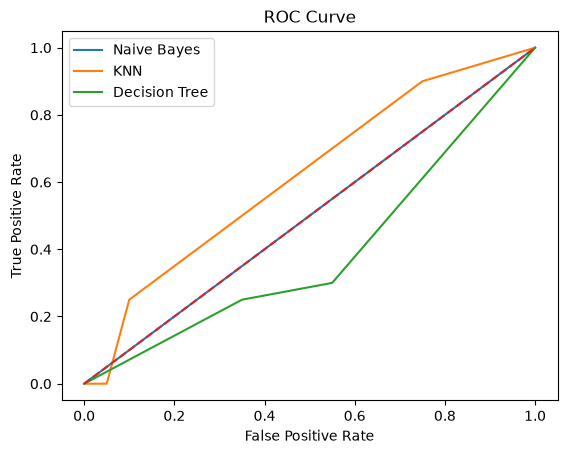

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve


fpr, tpr, _ = roc_curve(y_test, nb.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label="Naive Bayes")


fpr, tpr, _ = roc_curve(y_test, knn.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label="KNN")

fpr, tpr, _ = roc_curve(y_test, dt.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label="Decision Tree")


plt.plot([0,1], [0,1], "--") # Reference line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Phase 3: Reporting and Insights

## Model Comparison

Three machine learning classifiers were trained and evaluated to predict whether a food delivery would be **Fast** or **Delayed**. The models were assessed using Accuracy, Precision, Recall, and F1-Score.

### Performance Comparison

| Model | Accuracy | Precision | Recall | F1-Score |
|--------|---------:|----------:|-------:|---------:|
| Naive Bayes | **42.50%** | **0.42** | **0.42** | **0.42** |
| K-Nearest Neighbors (KNN) | **50.00%** | **0.50** | **0.50** | **0.50** |
| Decision Tree | **60.00%** | **0.60** | **0.60** | **0.60** |

---

# Best Model Recommendation

Based on the evaluation metrics, the **Decision Tree Classifier** is the recommended model for this project.

### Reasons

- Achieved the **highest accuracy (60%)**.
- Produced the **highest Precision, Recall, and F1-Score (0.60)**.


# Conclusion

Among the evaluated models, the **Decision Tree classifier** achieved the best overall performance with an accuracy of **60%**, making it the most suitable model for this dataset.